<a href="https://colab.research.google.com/github/Victorpc132/ProjetosPythonRauber/blob/main/01_Um_pouco_de_estat%C3%ADstica_para_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Um pouco de Estatística Fundamental para Machine Learning

Este notebook do Google Colab aprofunda nos conceitos estatísticos essenciais para qualquer pessoa que esteja iniciando seus estudos em Machine Learning. O objetivo é ir além das definições, mostrando a aplicação prática e a intuição por trás de cada conceito com exemplos de código em Python.

**Conceitos abordados:**
1.  Estatística Descritiva
2.  Probabilidade
3.  Estatística Inferencial
4.  Correlação e Regressão
5.  O Trade-off Viés-Variância

## 1. Estatística Descritiva: A Arte de Entender Seus Dados

Ir além da simples definição de média, mediana e desvio padrão é crucial. Pense na estatística descritiva como o "check-up médico" dos seus dados. Ela permite que você entenda a personalidade dos dados antes de construir qualquer modelo.

* **Implicações da Tendência Central:** A escolha entre **média** e **mediana** tem consequências práticas. A média é sensível a *outliers* (valores extremos), enquanto a mediana é robusta. Em ML, isso informa se você precisa tratar outliers antes de treinar o modelo.

* **O Poder da Dispersão:** O **desvio padrão** e a **variância** quantificam a "incerteza". Features com escalas muito diferentes podem fazer com que algoritmos sensíveis à distância deem um peso indevido à feature com maior escala. É por isso que técnicas como a **normalização** ou a **padronização** são passos essenciais no pré-processamento.

### Gráfico de BoxPlot
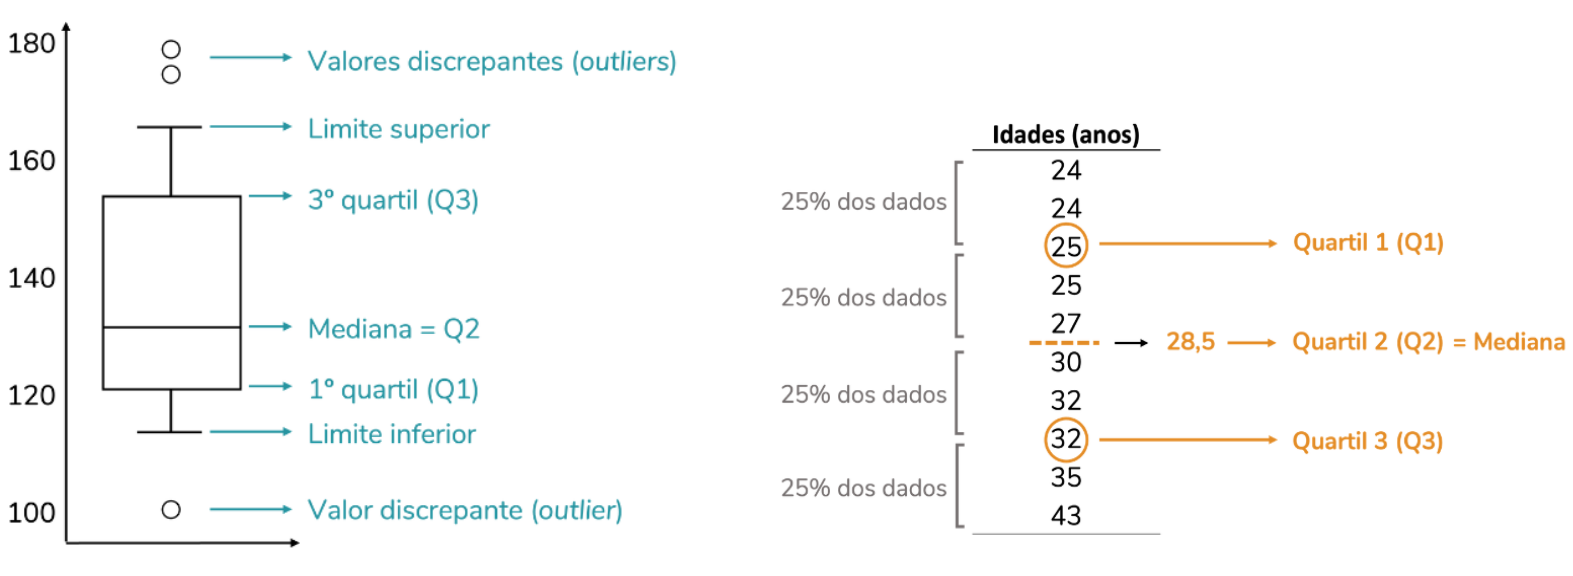
Imagens: https://fernandafperes.com.br/blog/interpretacao-boxplot/



Salários originais: [3, 4, 5, 5, 6, 7, 7, 8, 8, 8, 10]
Salários com outlier: [3, 4, 5, 5, 6, 7, 7, 8, 8, 8, 10, 150]

--- Análise Comparativa ---

Média sem outlier: 6.45
Mediana sem outlier: 7.00

Média com outlier: 18.42 (foi muito afetada!)
Mediana com outlier: 7.00 (permaneceu robusta)


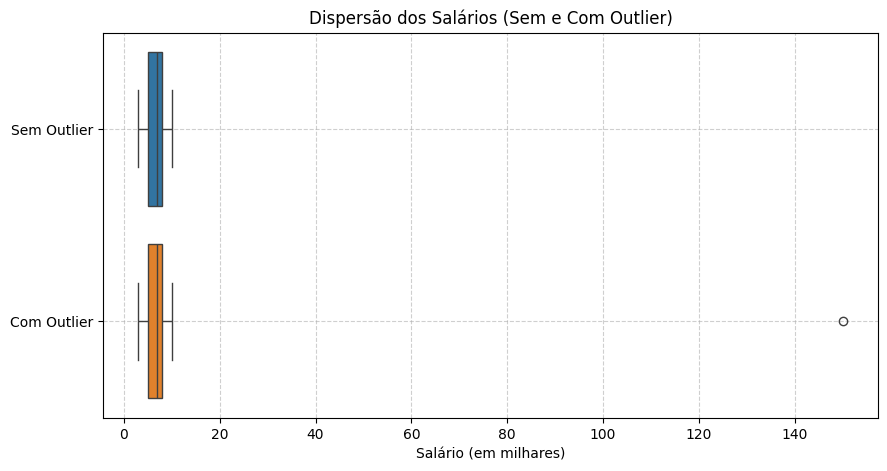


--- Resumo dos Dados originais ---
         Salário
count  11.000000
mean    6.454545
std     2.067058
min     3.000000
25%     5.000000
50%     7.000000
75%     8.000000
max    10.000000

--- Resumo dos Dados com outlier ---
          Salário
count   12.000000
mean    18.416667
std     41.484846
min      3.000000
25%      5.000000
50%      7.000000
75%      8.000000
max    150.000000


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Criando um conjunto de dados de salários (em milhares)
salarios = [3, 4, 5, 5, 6, 7, 7, 8, 8, 8, 10]

print(f"Salários originais: {salarios}")

# Adicionando um outlier (salário de um CEO)
salarios_com_outlier = salarios + [150]
print(f"Salários com outlier: {salarios_com_outlier}")

print("\n--- Análise Comparativa ---")
# Calculando média e mediana
media_sem_outlier = np.mean(salarios)
mediana_sem_outlier = np.median(salarios)

media_com_outlier = np.mean(salarios_com_outlier)
mediana_com_outlier = np.median(salarios_com_outlier)

print(f"\nMédia sem outlier: {media_sem_outlier:.2f}")
print(f"Mediana sem outlier: {mediana_sem_outlier:.2f}")
print(f"\nMédia com outlier: {media_com_outlier:.2f} (foi muito afetada!)")
print(f"Mediana com outlier: {mediana_com_outlier:.2f} (permaneceu robusta)")

# Visualizando a dispersão com um Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=[salarios, salarios_com_outlier], orient='h')
plt.title('Dispersão dos Salários (Sem e Com Outlier)')
plt.yticks([0, 1], ['Sem Outlier', 'Com Outlier'])
plt.xlabel('Salário (em milhares)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Um resumo dos dados originais
dados = pd.DataFrame({'Salário': salarios})
print("\n--- Resumo dos Dados originais ---")
print(dados.describe())

#Um resumo dos dados com outlier
dados_com = pd.DataFrame({'Salário': salarios_com_outlier})
print("\n--- Resumo dos Dados com outlier ---")
print(dados_com.describe())

## 2. Probabilidade: Quantificando a Incerteza e a Confiança

A probabilidade é a linguagem da incerteza. Modelos de ML fazem previsões com um certo grau de confiança probabilística.

* **Probabilidade Condicional e Teorema de Bayes:** Permite "inverter" a pergunta. Em vez de P(Sintoma | Doença), podemos calcular a probabilidade mais útil: P(Doença | Sintoma). Isso é a base de classificadores como o Naive Bayes.

* **Distribuições de Probabilidade:** A **Distribuição Normal (Gaussiana)** é a mais comum e muitos algoritmos assumem que os dados (ou os erros do modelo) a seguem. Conhecer as distribuições ajuda a modelar diferentes tipos de problemas e a validar as suposições dos modelos.

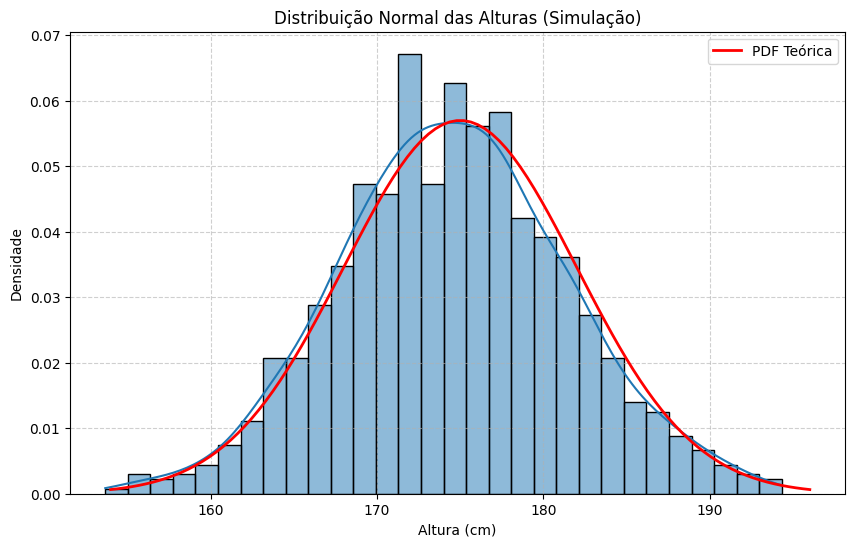

In [9]:
from scipy import stats

# Gerando dados de uma distribuição normal
# Ex: Simulação da altura de 1000 pessoas em cm
media_altura = 175
desvio_padrao_altura = 7

# Geramos 1000 amostras aleatórias seguindo essa distribuição
alturas = np.random.normal(loc=media_altura, scale=desvio_padrao_altura, size=1000)

# Plotando o histograma dos dados gerados
plt.figure(figsize=(10, 6))
sns.histplot(alturas, kde=True, stat="density", bins=30)

# Sobrepondo a curva da distribuição de probabilidade (PDF) teórica
x = np.linspace(media_altura - 3*desvio_padrao_altura, media_altura + 3*desvio_padrao_altura, 100)
plt.plot(x, stats.norm.pdf(x, media_altura, desvio_padrao_altura), 'r-', lw=2, label='PDF Teórica')

plt.title('Distribuição Normal das Alturas (Simulação)')
plt.xlabel('Altura (cm)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Estatística Inferencial: Generalizando a Partir de Amostras

A estatística inferencial usa uma **amostra** de dados para fazer generalizações sobre a **população**. É exatamente o que um modelo de ML faz: aprende com os dados de treino (amostra) para fazer previsões sobre dados novos (população).
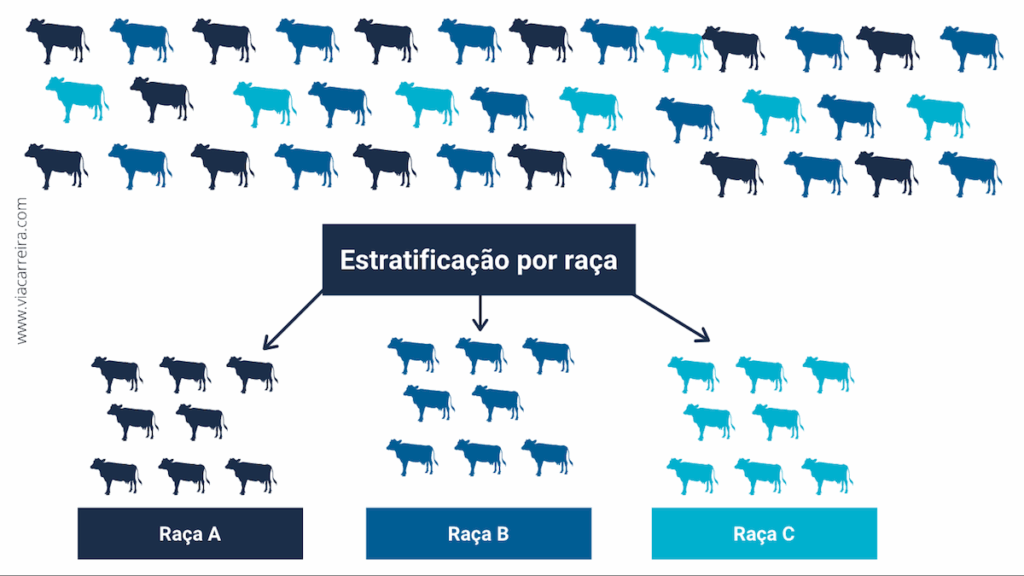
Imagem: https://viacarreira.com/amostra-de-pesquisa/

**Importante**:


- **Análise Estatística**: A amostra permite realizar inferências sobre a população sem a necessidade de analisar todos os elementos.

  
- **Custo e Tempo**: Trabalhar com uma amostra é geralmente mais econômico e rápido do que estudar toda a população.


- **Representatividade**: É crucial que a amostra seja representativa da população para garantir a validade dos resultados.

### *Teste de Hipóteses:*
Uma estrutura formal para validar uma suposição. Definimos uma **hipótese nula (H₀)** (geralmente afirmando que não há efeito) e uma **hipótese alternativa (H₁)**. O teste calcula o **p-valor**, que é a probabilidade de observar nossos dados se a hipótese nula for verdadeira. Um p-valor baixo (geralmente < 0.05) nos dá evidências para rejeitar a H₀. Isso é usado em ML para **A/B testing** de modelos ou **seleção de features**.

In [10]:
# Exemplo de Teste de Hipóteses (Teste A/B)
# H₀: O novo design do site (B) tem a mesma taxa de conversão que o antigo (A).
# H₁: O novo design (B) tem uma taxa de conversão diferente (ou maior).

# Gerando dados de conversão (1 = converteu, 0 = não converteu)
# Grupo A: 50 conversões em 1000 visitantes
grupo_a = np.array([1] * 50 + [0] * 950)
# Grupo B: 75 conversões em 1000 visitantes
grupo_b = np.array([1] * 75 + [0] * 950)

print(f"Taxa de conversão do Grupo A: {grupo_a.mean():.2%}")
print(f"Taxa de conversão do Grupo B: {grupo_b.mean():.2%}")

# Realizando um teste t de amostras independentes
t_stat, p_valor = stats.ttest_ind(grupo_a, grupo_b)

print(f"\nEstatística t: {t_stat:.2f}")
print(f"P-valor: {p_valor:.4f}")

# Interpretando o resultado
alpha = 0.05
if p_valor < alpha:
    print("\nResultado: Rejeitamos a hipótese nula.")
    print("A diferença na taxa de conversão é estatisticamente significativa.")
else:
    print("\nResultado: Não podemos rejeitar a hipótese nula.")
    print("A diferença observada pode ser devida ao acaso.")

Taxa de conversão do Grupo A: 5.00%
Taxa de conversão do Grupo B: 7.32%

Estatística t: -2.17
P-valor: 0.0303

Resultado: Rejeitamos a hipótese nula.
A diferença na taxa de conversão é estatisticamente significativa.


## 4. Correlação e Regressão: Modelando Relações

* **Correlação:** Mede a força e a direção da relação entre duas variáveis. **Importante:** correlação não implica causalidade! Existe uma forte correlação entre vendas de sorvete e ataques de tubarão, mas a causa comum é o calor do verão.

* **Regressão:** É um método para modelar essa relação e fazer previsões. A **Regressão Linear** tenta encontrar a linha reta que melhor se ajusta aos dados. O processo de "treinar" o modelo é encontrar os melhores coeficientes (pesos) para essa linha.

Horas de Estudo: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Notas no Exame: [50, 55, 68, 72, 75, 80, 88, 90, 92, 98]

Coeficiente de Correlação de Pearson: 0.98


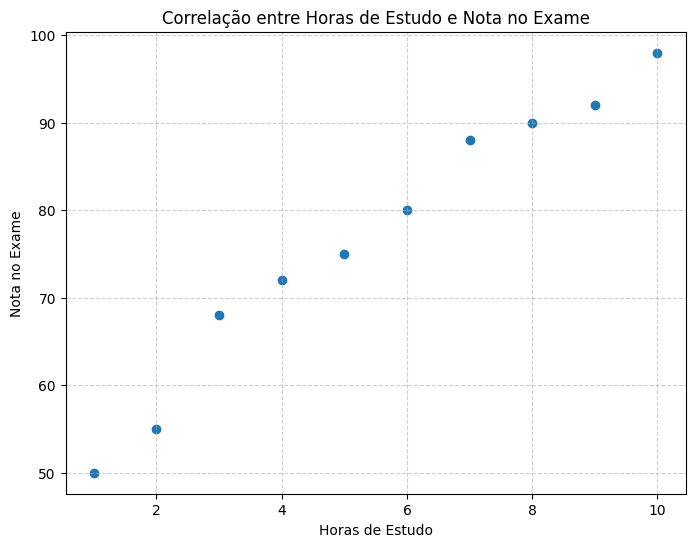

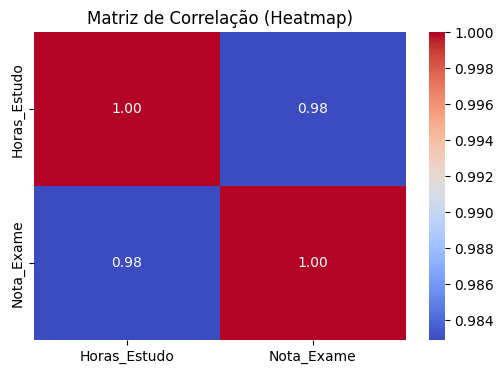

In [11]:
# Exemplo de Correlação entre duas variáveis
# Vamos criar dados sintéticos para "Horas de Estudo" e "Nota no Exame"
# Esperamos uma correlação positiva: quanto mais horas de estudo, maior a nota.

horas_estudo = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
notas_exame = [50, 55, 68, 72, 75, 80, 88, 90, 92, 98]

# Calculando o coeficiente de correlação de Pearson
# O coeficiente varia de -1 (correlação negativa perfeita) a +1 (correlação positiva perfeita)
# 0 indica ausência de correlação linear.
coeficiente_correlacao = np.corrcoef(horas_estudo, notas_exame)[0, 1]

print(f"Horas de Estudo: {horas_estudo}")
print(f"Notas no Exame: {notas_exame}")
print(f"\nCoeficiente de Correlação de Pearson: {coeficiente_correlacao:.2f}")

# Visualizando a correlação com um Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(horas_estudo, notas_exame)
plt.title('Correlação entre Horas de Estudo e Nota no Exame')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota no Exame')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Visualizando a matriz de correlação com um Heatmap
df = pd.DataFrame({'Horas_Estudo': horas_estudo, 'Nota_Exame': notas_exame})
correlacao_matrix = df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlacao_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação (Heatmap)')
plt.show()

### Interpretando a Matriz de Correlação (Heatmap)

O mapa de calor da matriz de correlação nos ajuda a visualizar a força e a direção da relação linear entre as variáveis.

* **Cores e Valores:**
    * **Cores mais quentes (vermelho):** Indicam correlação positiva forte (quanto maior uma variável, maior a outra). Um valor de 1.00 (como na diagonal) significa uma correlação perfeita de uma variável consigo mesma.
    * **Cores mais frias (azul):** Indicam correlação negativa forte (quanto maior uma variável, menor a outra).
    * **Cores próximas a zero (branco/cinza):** Indicam pouca ou nenhuma correlação linear.

* **Nosso Exemplo:**
    * O valor **0.98** na intersecção de "Horas_Estudo" e "Nota_Exame" (e vice-versa) mostra uma **correlação positiva muito forte**. Isso confirma nossa expectativa: quanto mais horas de estudo, maior a nota no exame.
    * A diagonal com valores **1.00** é esperada, pois uma variável sempre tem correlação perfeita consigo mesma.

Essa visualização é útil para identificar rapidamente quais variáveis em um conjunto de dados podem ter relações lineares fortes, o que pode ser um passo importante na seleção de features para um modelo de Machine Learning.

Matriz de Correlação:
              horas_estudo  notas_exame
horas_estudo      1.000000     0.982903
notas_exame       0.982903     1.000000


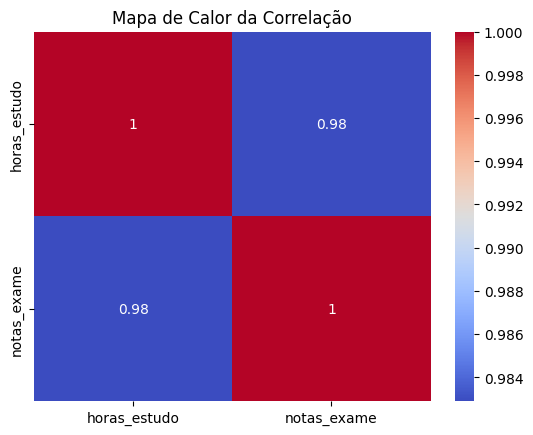


Intercepto (β₀): 48.33 (Nota esperada com 0h de estudo)
Coeficiente (β₁): 5.18 (Aumento na nota por hora de estudo)


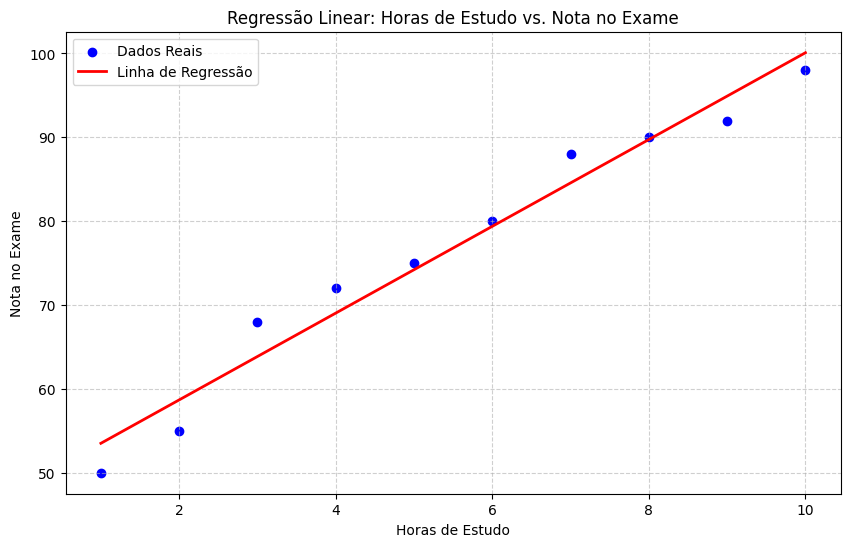

In [12]:
from sklearn.linear_model import LinearRegression

# Criando dados sintéticos: horas de estudo vs. nota no exame
horas_estudo = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
notas_exame = np.array([50, 55, 68, 72, 75, 80, 88, 90, 92, 98])

# --- Correlação ---
df = pd.DataFrame({'horas_estudo': horas_estudo.flatten(), 'notas_exame': notas_exame})
correlacao = df.corr()
print("Matriz de Correlação:")
print(correlacao)
sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Mapa de Calor da Correlação')
plt.show()

# --- Regressão Linear ---
# Criando o modelo
modelo_regressao = LinearRegression()

# Treinando o modelo (encontrando a melhor linha)
modelo_regressao.fit(horas_estudo, notas_exame)

# Obtendo os parâmetros do modelo
intercepto = modelo_regressao.intercept_ # Coeficiente β₀
coeficiente = modelo_regressao.coef_[0]   # Coeficiente β₁

print(f"\nIntercepto (β₀): {intercepto:.2f} (Nota esperada com 0h de estudo)")
print(f"Coeficiente (β₁): {coeficiente:.2f} (Aumento na nota por hora de estudo)")

# Visualizando a regressão
plt.figure(figsize=(10, 6))
plt.scatter(horas_estudo, notas_exame, color='blue', label='Dados Reais')
plt.plot(horas_estudo, modelo_regressao.predict(horas_estudo), color='red', linewidth=2, label='Linha de Regressão')
plt.title('Regressão Linear: Horas de Estudo vs. Nota no Exame')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota no Exame')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. A relação (Trade-off) entre Viés-Variância: O Dilema Central do ML

Este é o conceito mais importante para diagnosticar a performance de um modelo. O objetivo é encontrar um equilíbrio entre um modelo muito simples e um muito complexo.

* **Viés (Bias):** Erro de um modelo excessivamente **simples**. O modelo não consegue capturar a complexidade dos dados. Isso leva ao **subajuste (underfitting)**.

* **Variância:** Erro de um modelo excessivamente **complexo**. O modelo "decora" o ruído dos dados de treino em vez de aprender o padrão geral. Ele se sai mal em dados novos. Isso leva ao **sobreajuste (overfitting)**.

Usaremos um exemplo visual para demonstrar: tentaremos ajustar modelos de diferentes complexidades a dados que seguem uma curva.

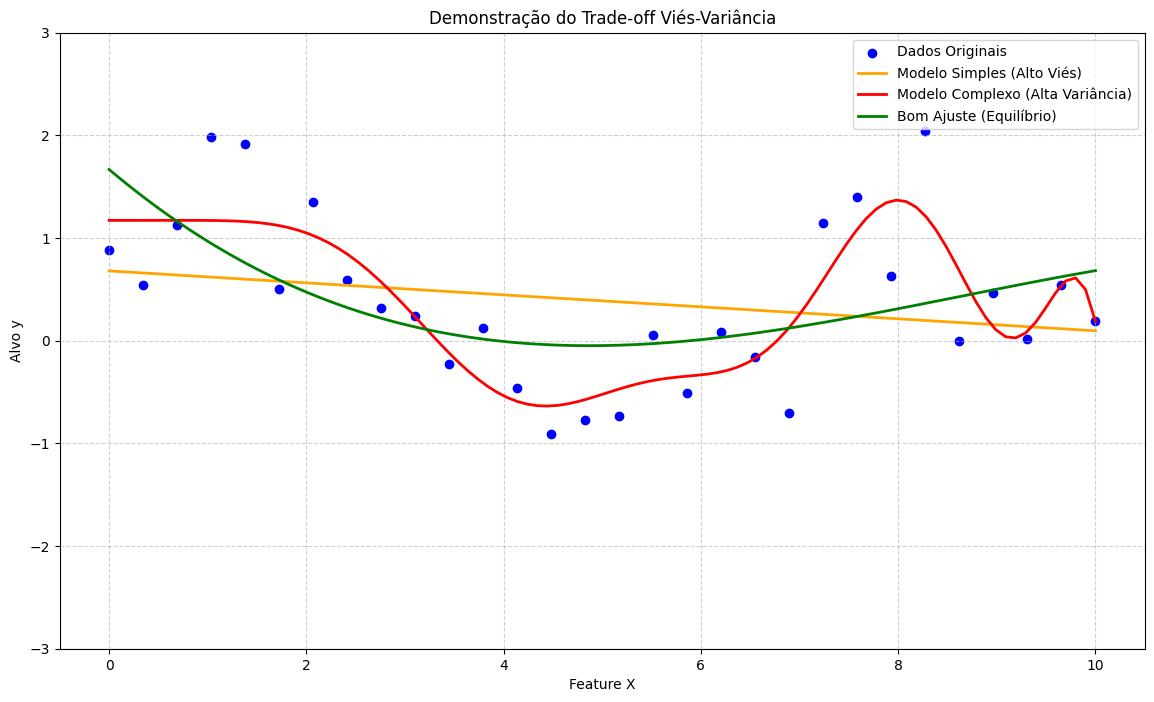

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Gerando dados não-lineares (uma curva senoidal com ruído)
np.random.seed(0)
X = np.linspace(0, 10, 30).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 30)

plt.figure(figsize=(14, 8))
plt.scatter(X, y, color='blue', label='Dados Originais')

# 1. Underfitting (Alto Viés): Modelo muito simples (Regressão Linear)
modelo_simples = LinearRegression()
modelo_simples.fit(X, y)
plt.plot(X, modelo_simples.predict(X), color='orange', linewidth=2, label='Modelo Simples (Alto Viés)')

# 2. Overfitting (Alta Variância): Modelo muito complexo (Polinômio de grau 15)
modelo_complexo = make_pipeline(PolynomialFeatures(15), LinearRegression())
modelo_complexo.fit(X, y)
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(X_plot, modelo_complexo.predict(X_plot), color='red', linewidth=2, label='Modelo Complexo (Alta Variância)')

# 3. Bom Ajuste: Modelo com a complexidade certa (Polinômio de grau 3)
modelo_ideal = make_pipeline(PolynomialFeatures(3), LinearRegression())
modelo_ideal.fit(X, y)
plt.plot(X_plot, modelo_ideal.predict(X_plot), color='green', linewidth=2, label='Bom Ajuste (Equilíbrio)')

plt.title('Demonstração do Trade-off Viés-Variância')
plt.xlabel('Feature X')
plt.ylabel('Alvo y')
plt.legend()
plt.ylim(-3, 3)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Avaliando o desempenho dos modelos
# Atenção: apenas para exemplo. Em casos reais fazer isso com o grupo de testes.
y_true = y  # Os valores reais

# Modelo Simples (Alto Viés)
y_pred_simples = modelo_simples.predict(X)
mse_simples = mean_squared_error(y_true, y_pred_simples)
rmse_simples = np.sqrt(mse_simples) # Calculando RMSE
mae_simples = mean_absolute_error(y_true, y_pred_simples) # Calculando MAE
r2_simples = r2_score(y_true, y_pred_simples)

print("\n--- Desempenho do Modelo Simples (Alto Viés) ---")
print(f"Erro Médio Quadrático (MSE): {mse_simples:.2f}")
print(f"Raiz do Erro Médio Quadrático (RMSE): {rmse_simples:.2f}")
print(f"Erro Médio Absoluto (MAE): {mae_simples:.2f}")
print(f"Coeficiente de Determinação (R²): {r2_simples:.2f}")

# Modelo Complexo (Alta Variância)
y_pred_complexo = modelo_complexo.predict(X)
mse_complexo = mean_squared_error(y_true, y_pred_complexo)
rmse_complexo = np.sqrt(mse_complexo) # Calculando RMSE
mae_complexo = mean_absolute_error(y_true, y_pred_complexo) # Calculando MAE
r2_complexo = r2_score(y_true, y_pred_complexo)

print("\n--- Desempenho do Modelo Complexo (Alta Variância) ---")
print(f"Erro Médio Quadrático (MSE): {mse_complexo:.2f}")
print(f"Raiz do Erro Médio Quadrático (RMSE): {rmse_complexo:.2f}")
print(f"Erro Médio Absoluto (MAE): {mae_complexo:.2f}")
print(f"Coeficiente de Determinação (R²): {r2_complexo:.2f}")


# Modelo Ideal (Equilíbrio)
y_pred_ideal = modelo_ideal.predict(X)
mse_ideal = mean_squared_error(y_true, y_pred_ideal)
rmse_ideal = np.sqrt(mse_ideal) # Calculando RMSE
mae_ideal = mean_absolute_error(y_true, y_pred_ideal) # Calculando MAE
r2_ideal = r2_score(y_true, y_pred_ideal)


print("\n--- Desempenho do Modelo Ideal (Equilíbrio) ---")
print(f"Erro Médio Quadrático (MSE): {mse_ideal:.2f}")
print(f"Raiz do Erro Médio Quadrático (RMSE): {rmse_ideal:.2f}")
print(f"Erro Médio Absoluto (MAE): {mae_ideal:.2f}")
print(f"Coeficiente de Determinação (R²): {r2_ideal:.2f}")


print("\n--- Resumo Comparativo ---")
comparativo = pd.DataFrame({
    'Modelo': ['Simples (Alto Viés)', 'Complexo (Alta Variância)', 'Ideal (Equilíbrio)'],
    'MSE': [mse_simples, mse_complexo, mse_ideal],
    'RMSE': [rmse_simples, rmse_complexo, rmse_ideal],
    'MAE': [mae_simples, mae_complexo, mae_ideal],
    'R²': [r2_simples, r2_complexo, r2_ideal]
})
print(comparativo.round(2))


--- Desempenho do Modelo Simples (Alto Viés) ---
Erro Médio Quadrático (MSE): 0.62
Raiz do Erro Médio Quadrático (RMSE): 0.79
Erro Médio Absoluto (MAE): 0.62
Coeficiente de Determinação (R²): 0.05

--- Desempenho do Modelo Complexo (Alta Variância) ---
Erro Médio Quadrático (MSE): 0.20
Raiz do Erro Médio Quadrático (RMSE): 0.45
Erro Médio Absoluto (MAE): 0.36
Coeficiente de Determinação (R²): 0.69

--- Desempenho do Modelo Ideal (Equilíbrio) ---
Erro Médio Quadrático (MSE): 0.46
Raiz do Erro Médio Quadrático (RMSE): 0.68
Erro Médio Absoluto (MAE): 0.53
Coeficiente de Determinação (R²): 0.29

--- Resumo Comparativo ---
                      Modelo   MSE  RMSE   MAE    R²
0        Simples (Alto Viés)  0.62  0.79  0.62  0.05
1  Complexo (Alta Variância)  0.20  0.45  0.36  0.69
2         Ideal (Equilíbrio)  0.46  0.68  0.53  0.29


## Resumo de Métricas de Avaliação em Machine Learning

| Métrica                     | Descrição                                                                                                | Tipo de Problema      |
| :-------------------------- | :------------------------------------------------------------------------------------------------------- | :-------------------- |
| **Erro Médio Quadrático (MSE)** | Média dos quadrados dos erros entre os valores previstos e reais. Penaliza erros grandes.                | Regressão             |
| **Raiz do Erro Médio Quadrático (RMSE)** | Raiz quadrada do MSE. Tem a mesma unidade da variável alvo, o que facilita a interpretação.                         | Regressão             |
| **Erro Médio Absoluto (MAE)** | Média dos valores absolutos dos erros. É menos sensível a *outliers* que o MSE/RMSE.                          | Regressão             |
| **Coeficiente de Determinação (R²)** | Proporção da variância na variável alvo que é previsível a partir das variáveis independentes. Varia de 0 a 1 (idealmente). | Regressão             |
| **Acurácia (Accuracy)**     | Proporção de previsões corretas (verdadeiros positivos + verdadeiros negativos) sobre o total de casos.    | Classificação         |
| **Precisão (Precision)**    | Proporção de verdadeiros positivos entre todos os casos preditos como positivos. Importante para evitar falsos positivos. | Classificação         |
| **Recall (Revocação)**      | Proporção de verdadeiros positivos entre todos os casos reais positivos. Importante para evitar falsos negativos. | Classificação         |
| **F1-Score**                | Média harmônica da Precisão e Recall. Busca um equilíbrio entre as duas métricas.                           | Classificação         |
| **Área sob a Curva ROC (AUC-ROC)** | Mede a capacidade de um modelo de classificação de distinguir entre classes. Varia de 0 a 1 (0.5 é aleatório, 1 é perfeito). | Classificação Binária |

## Conclusão

Dominar esses cinco pilares da estatística fornece a intuição necessária não apenas para *usar* algoritmos de Machine Learning, mas para *entender* seu funcionamento, diagnosticar problemas e, finalmente, construir modelos mais eficazes e confiáveis.

O material aqui apresentado é uma visão superficial e mera introdução a esses tópicos.